# Second order High Pass Shelving Filter using op-amp for audio
Last update: 24 Feb 2026  

[Second order High Pass Shelving Filter using op-amp for audio](https://electronics.stackexchange.com/questions/754829/second-order-high-pass-shelving-filter-using-op-amp-for-audio)

I am looking for op-amp based second order high pass shelving filter whose corner is set at 25Hz and by 18Hz it should be 15dB to 18dB down. That's quite a steep roll-off. While there are other filters that can give the needed slope, they all have excess group delay because they keep attenuating as we go lower in frequency. But shelving HPF is different, it levels off below the 18Hz and stays at that level (-15dB to -18dB) as we go lower in frequency. Please keep the group delay discussion out of topic. I will calculate the group delay and report back here once somebody gives or points me to a proper schematic.

Can somebody please help with such a shelving HPF?

These kind of filters have moved to DSP these days and very less info is available on the net, but I want to stay with op-amp and would appreciate if somebody could help. I am told there are several ways to do it, one of them is Linkwitz Transform circuit, but I could never get the sharp roll-off needed. I am sure elegant solutions exist.

Thanks and Warm Regards, WonderfulIOT

The filter graph is below:

The full article is here https://audioxpress.com/files/attachment/2721

I am attaching the below 2nd order shelving filter from TI: 

---

>I believe even a biquad can do it. –   
wonderfuliot  
Commented Sep 3, 2025 at 8:43

>To put it in simple terms, you want a -3 dB pole corner at 25 Hz that goes to 0 dB at HF, and another 3 dB zero corner at -15 dB that goes to -18 dB towards DC? Is that about 36 dB per decade around 21 Hz? (I'm doing this in my head and may be screwing up.) Or am I missing it? –   
periblepsis  
Commented Sep 3, 2025 at 9:01

>I have added filter graph also to the original question now –   
wonderfuliot  
Commented Sep 3, 2025 at 10:04  

>Vastly improved. I've added my own edit to get the image to display properly. It is much easier to see the Q and the poles and zeros and their order, now. I'll +1 the question. –  
periblepsis  
Commented Sep 3, 2025 at 10:09  

>That's a very steep slope to achieve with an analog circuit. That's why it's done digitally. –   
Carl Rutschow  
Commented Sep 3, 2025 at 14:41  

>Why does the slope need to be that steep? –   
Carl Rutschow  
Commented Sep 3, 2025 at 15:56  

>Carl, the filter is designed for subwoofer excursion limiting. Actually, at the tuning frequency of the bass reflex box (ie 25Hz) the subwoofer gets fully loaded, the cone moves little but there is tremendous output from port, all is good. However, when we reach 0.707x25Hz, ie 18Hz the subwoofer driver is totally unloaded and the subwoofer driver experiences huge excursions without producing any acoustic output, it just distorts, so in the narrow range from 25Hz to 18Hz, a steeper filter is needed. –   
wonderfuliot  
Commented Sep 4, 2025 at 5:59  

>The typical textbook filters like Butterworth, Bessel, Sallen-Key etc all are ever attenuating filter and their high group delay is a problem sonically, so a shelving filter which attenuates with a high slope but only uptill -15dB@18Hz and then LEVELS OFF, produces less group delay. -15dB is not audible compared to reference 0dB so the filter works well –   
wonderfuliot  
Commented Sep 4, 2025 at 6:01  

>Carl, one more thing, the shelving filters that they use in DSP are based on analog equivalent so I want to take the analogue route, plus there is an extra ADC/DAC step which I dont like. I am sure a quad package op-amp can do the filter if somebody provides me a direction – 
wonderfuliot  
Commented Sep 4, 2025 at 10:03  

---

My proposed solution follows the design steps for a Linkwitz filter described in the paper, [Equalization of the closed box](https://jahonen.kapsi.fi/Audio/Papers/Equalization.pdf), by Janne Ahonen. The original work on this filter was published by Siegfried Linkwitz in [Loudspeaker system design, Three-enclosure system with active delay and crossovers](https://www.linkwitzlab.com/Removed%20pages/x-sb80-3wy.htm). The filter's transfer function and design equations were copied into a JupyterLab notebook. What you see below are parts of the notebook pasted into the answer dialog box. The JupyterLab notebook is available on GitHub and linked [here](), a repository is owned by me.  

The resulting filter almost meets your design goals at the 18 and 25 Hz corner frequencies. Additional comments about the filter's performance are included at the end of my answer.

The following Python libraries are used in the calculations.

In [11]:
from sympy import *
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math, Latex
init_printing()

The transfer function for the Linkwitz filter was obtained from Equation 3.15 in Janne Ahonen's paper cited above. SymPy variables are declared and the equation is entered into the code cell below. 

In [12]:
R1, R2, R3, C1, C2, C3, s = symbols('R1, R2, R3, C1, C2, C3, s')

H_sym = (-R3*(C3*R3*s+2)*(C1*C2*R1**2*s**2+(2*C2*R1+C2*R2)*s+1))/(R1*(C1*R1*s+2)*(C2*C3*R3**2*s**2+(2*C2*R3+C2*R2)*s+1))
Markdown('$H(s)={:s}$'.format(latex(H_sym)))

$H(s)=- \frac{R_{3} \left(C_{3} R_{3} s + 2\right) \left(C_{1} C_{2} R_{1}^{2} s^{2} + s \left(2 C_{2} R_{1} + C_{2} R_{2}\right) + 1\right)}{R_{1} \left(C_{1} R_{1} s + 2\right) \left(C_{2} C_{3} R_{3}^{2} s^{2} + s \left(C_{2} R_{2} + 2 C_{2} R_{3}\right) + 1\right)}$

As you can see, the terms in numerator and denominator have been factored. The quadratic term, $\left(C_{1} C_{2} R_{1}^{2} s^{2} + s \left(2 C_{2} R_{1} + C_{2} R_{2}\right) + 1\right)$, in the numerator can be expressed in terms of $\omega$, the natural frequency and the [Q factor](https://en.wikipedia.org/wiki/Q_factor), $s^2+\frac{\omega}{Q}+\omega^2$.

The $\omega$'s and Q factors for the numerator and denominator quadratic terms are used in the design equations. The variables below: `wo`, `Qo`, `wp` and `Qp`, are these $\omega$'s and Q's. The Python code was run several times, before settling on the frequency break points of 13 and 32 Hz, with Q's of 1.75. These values seem to give results that best match your design goals.   

In [13]:
wo = 2*np.pi*13
Qo = 1.75
wp = 2*np.pi*32
Qp = 1.75

The following calculations walk through the design steps:

Calculate the constant $k$; $k \gt 0$ for a realizable network.

In [14]:
k = (wo/wp-Qo/Qp)/(Qo/Qp-wp/wo)
print(f'k constant: {k:.3}')

k constant: 0.406


Choose a value for $C_2$. A value of 0.02$\mu$F produces reasonable values for the other components.

In [15]:
C2n = 0.02e-6

These design formulas are provided in the reference papers.

In [16]:
R1n = 1/(wo*C2n*(2*Qo*(1+k)))
R2n = 2*k*R1n
C1n = C2n*(2*Qo*(1+k))**2
C3n = C1n*(wp/wo)**2
R3n = R1n*(wo/wp)**2

The calculated component values are displayed below. 

In [17]:
element_values = {R1:R1n, R2:R2n, R3:R3n, C1:C1n, C2:C2n, C3:C3n}

# display the component values
for k,v in element_values.items():
    if str(k)[0] == 'R':
        print('{:s} = {:,.3f} K'.format(str(k), v/1e3))
    else:
        print('{:s} = {:,.3f} uF'.format(str(k), v*1e6))

R1 = 124.370 K
R2 = 101.051 K
R3 = 20.526 K
C1 = 0.484 uF
C2 = 0.020 uF
C3 = 2.936 uF


As you can see, these are not standard component values for resistors and capacitors. Since this is a preliminary design, I'm going to use these numbers to calculate the frequency response plot shown below. The values are shown in the LTSpice schematic below.

![](Linkwitz_Circuit_chk_sim.png)

The calculated values are substituted into the transfer function. 

In [18]:
H = H_sym.subs(element_values)

The following code converts the numerator and denominator into NumPy polynomials.

In [19]:
H_num, H_denom = fraction(H)

# convert symbolic to NumPy polynomial
a = np.array(Poly(H_num, s).all_coeffs(), dtype=float)
b = np.array(Poly(H_denom, s).all_coeffs(), dtype=float)

The following code displays the frequency response plot using SciPy functions. The magnitude (plotted in blue) and phase (plotted in dashed red) of the transfer function is plotted along with highlighted stop and pass band regions (in light gray). Two markers are also drawn on the magnitude plot at 18 and 25 Hz.  

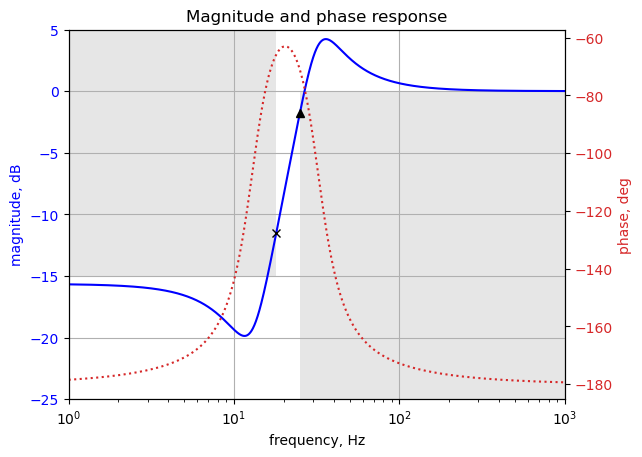

In [20]:
x = np.logspace(0, 3, 2000, endpoint=False)*2*np.pi
w, mag, phase = signal.bode((a, b), w=x) # returns: rad/s, mag in dB, phase in deg

fig, ax1 = plt.subplots()
ax1.set_xlabel('frequency, Hz')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylabel('magnitude, dB', color='b')

plt.semilogx(w/(2*np.pi), mag,'-b') # Bode magnitude plot

fp = 25 # pass band edge frequency, Hz
gpass = 0 # The maximum loss in the pass band (dB)

fs = 18 # stop band edge frequency, Hz
gstop = 15 # The minimum attenuation in the stop band (dB)

plt.fill([100e9, fp,  fp,  100e9], [-gpass, -gpass, -100, -100], '0.9', lw=0) # pass band
plt.fill([fs, fs, 0, 0], [-gstop, 100, 100, -gstop], '0.9', lw=0) # stop band
plt.xlim((1,1000))
plt.ylim((-25,5))
plt.grid()

# mark the 25Hz point
p1 = np.where(w > 25*(2*np.pi))[0][0]
plt.semilogx(w[p1]/(2*np.pi), mag[p1],'^k')

# mark the 18Hz point
p1 = np.where(w > 18*(2*np.pi))[0][0]
plt.semilogx(w[p1]/(2*np.pi), mag[p1],'xk')

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'

plt.semilogx(w/(2*np.pi), phase,':',color='tab:red')  # Bode phase plot

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')

plt.show()

As you can see, this iteration of the design has the magnitude plot cutting into the stop and pass band areas, which fails to meet your design goals, albeit by a small amount. The results were verified by LTSpice simulation. 

I would regard the results presented here as very preliminary. If you require a steeper transition, perhaps two filter sections can be cascaded. You would need to judicially choose a new family of poles and zeros to implement for each section. Additionally, the design needs to be finalized so that standard component values are used. At some point you should also perform a sensitivity and tolerance analysis if you want to proceed forward.